In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim

import xgboost as xgb

In [13]:


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ======= load your CSV =======
CSV_PATH = '/content/drive/MyDrive/california-housing.csv'  # change if needed
df = pd.read_csv(CSV_PATH)

# Expect last column as target (MedHouseVal). If not, adjust here.
X = df.iloc[:, :-1].values.astype(np.float32)  # features
y = df.iloc[:, -1].values.astype(np.float32).reshape(-1, 1)  # target as (N,1)

# Train/test split (keep it simple — your notebook style)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)

# Scale X and y (like in your notebook)
X_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train)

X_train = X_scaler.transform(X_train).astype(np.float32)
X_test  = X_scaler.transform(X_test).astype(np.float32)

y_train = y_scaler.transform(y_train).astype(np.float32)
y_test  = y_scaler.transform(y_test).astype(np.float32)


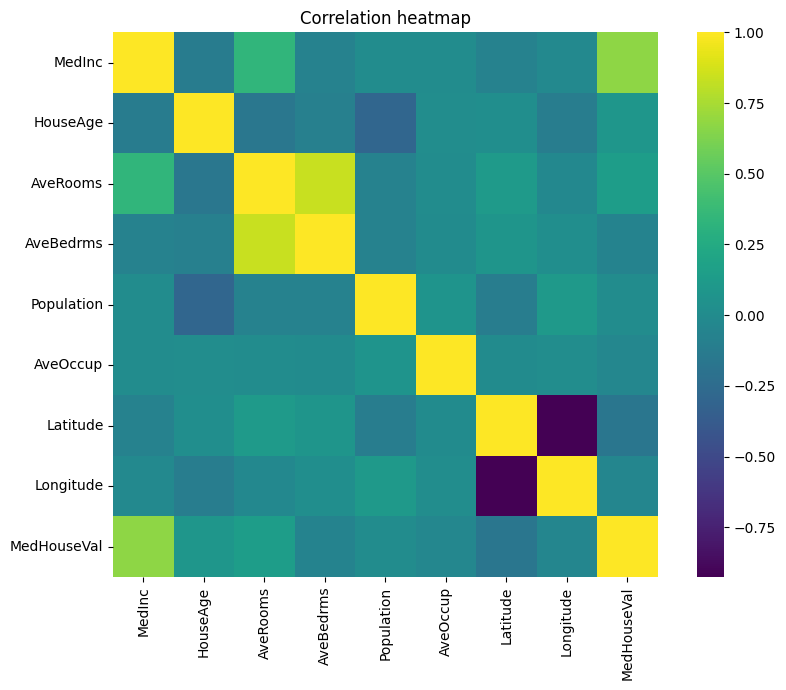

In [14]:
plt.figure(figsize=(9,7))
sns.heatmap(pd.DataFrame(np.hstack([X, y]),
                         columns=list(df.columns[:-1]) + [df.columns[-1]]).corr(),
            cmap="viridis", square=True)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()


In [15]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)  # (N,1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)  # (N,1)



Training Linear Regression model...
Epoch [10/50], Loss: 0.7409
Epoch [20/50], Loss: 0.6001
Epoch [30/50], Loss: 0.5259
Epoch [40/50], Loss: 0.4852
Epoch [50/50], Loss: 0.4664


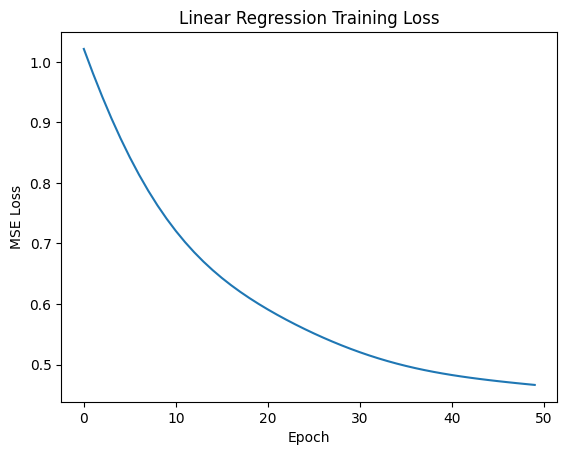


Linear Regression Results:
R² = 0.5280, MSE = 0.0597, MAE = 0.1907


In [16]:
class LinearRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.linear(x)

input_dim = X_train.shape[1]
lin_model = LinearRegressor(input_dim)

criterion = nn.MSELoss()
optimizer = optim.Adam(lin_model.parameters(), lr=0.01)

epochs = 50
train_losses = []
print("\nTraining Linear Regression model...")
for epoch in range(epochs):
    lin_model.train()
    optimizer.zero_grad()
    outputs = lin_model(X_train_t)           # (N,1)
    loss = criterion(outputs, y_train_t)     # (N,1)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

plt.plot(train_losses)
plt.title("Linear Regression Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# Evaluate (inverse-transform predictions)
lin_model.eval()
with torch.no_grad():
    preds_scaled = lin_model(X_test_t).cpu().numpy()          # (N,1) in scaled space
    preds = y_scaler.inverse_transform(preds_scaled)          # back to original scale
    y_true = y_scaler.inverse_transform(y_test)               # original scale

r2_lin = r2_score(y_true, preds)
mse_lin = mean_squared_error(y_true, preds)
mae_lin = mean_absolute_error(y_true, preds)

print(f"\nLinear Regression Results:")
print(f"R² = {r2_lin:.4f}, MSE = {mse_lin:.4f}, MAE = {mae_lin:.4f}")



Training MLP Regressor...
Epoch [10/50], Loss: 0.8879
Epoch [20/50], Loss: 0.7335
Epoch [30/50], Loss: 0.5878
Epoch [40/50], Loss: 0.4842
Epoch [50/50], Loss: 0.4376


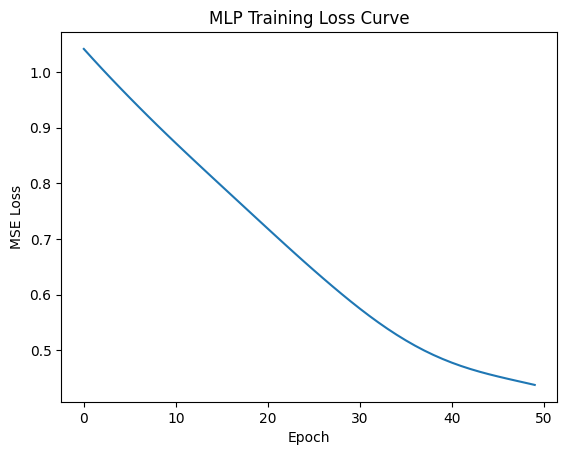


MLP Regressor Results:
R² = 0.5512, MSE = 0.0567, MAE = 0.1853


In [18]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

mlp_model = MLPRegressor(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

print("\nTraining MLP Regressor...")
epochs = 50
mlp_losses = []

for epoch in range(epochs):
    mlp_model.train()
    optimizer.zero_grad()
    outputs = mlp_model(X_train_t)          # (N,1) scaled
    loss = criterion(outputs, y_train_t)    # (N,1) scaled
    loss.backward()
    optimizer.step()
    mlp_losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

plt.plot(mlp_losses)
plt.title("MLP Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# Evaluate
mlp_model.eval()
with torch.no_grad():
    preds_scaled = mlp_model(X_test_t).cpu().numpy()
    preds = y_scaler.inverse_transform(preds_scaled)

r2_mlp = r2_score(y_true, preds)
mse_mlp = mean_squared_error(y_true, preds)
mae_mlp = mean_absolute_error(y_true, preds)

print(f"\nMLP Regressor Results:")
print(f"R² = {r2_mlp:.4f}, MSE = {mse_mlp:.4f}, MAE = {mae_mlp:.4f}")


In [21]:
print("\nTraining XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1
)
# Train on scaled y (1D)
xgb_model.fit(X_train, y_train.ravel())

xgb_preds_scaled = xgb_model.predict(X_test).reshape(-1,1)   # scaled predictions
xgb_preds = y_scaler.inverse_transform(xgb_preds_scaled)     # original scale

r2_xgb = r2_score(y_true, xgb_preds)
mse_xgb = mean_squared_error(y_true, xgb_preds)
mae_xgb = mean_absolute_error(y_true, xgb_preds)

print(f"\nXGBoost Regressor Results:")
print(f"R² = {r2_xgb:.4f}, MSE = {mse_xgb:.4f}, MAE = {mae_xgb:.4f}")



Training XGBoost Regressor...

XGBoost Regressor Results:
R² = 0.8448, MSE = 0.0196, MAE = 0.1000


In [9]:
regressor = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)
regressor.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)


=== Comparison (original scale) ===
Linear  : R²=0.5280 | MSE=0.0597 | MAE=0.1907
MLP     : R²=0.5512 | MSE=0.0567 | MAE=0.1853
XGBoost : R²=0.8448 | MSE=0.0196 | MAE=0.1000

Best model by R²: XGBoost  =>  0.8448


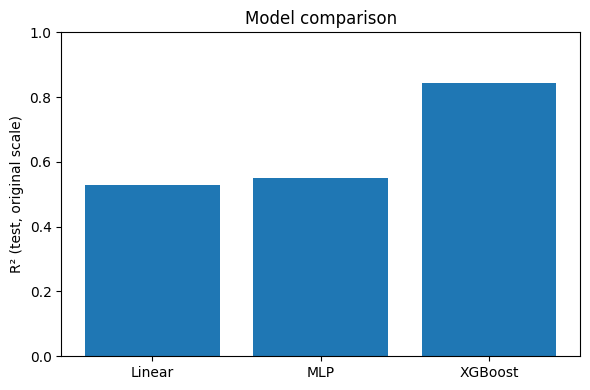

In [19]:
# Table
print("\n=== Comparison (original scale) ===")
print(f"Linear  : R²={r2_lin:.4f} | MSE={mse_lin:.4f} | MAE={mae_lin:.4f}")
print(f"MLP     : R²={r2_mlp:.4f} | MSE={mse_mlp:.4f} | MAE={mae_mlp:.4f}")
print(f"XGBoost : R²={r2_xgb:.4f} | MSE={mse_xgb:.4f} | MAE={mae_xgb:.4f}")

scores = {
    "Linear":  r2_lin,
    "MLP":     r2_mlp,
    "XGBoost": r2_xgb
}
best_name = max(scores, key=scores.get)
print(f"\nBest model by R²: {best_name}  =>  {scores[best_name]:.4f}")

# Bar plot
plt.figure(figsize=(6,4))
plt.bar(scores.keys(), scores.values())
plt.ylabel("R² (test, original scale)")
plt.title("Model comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [23]:
# Export the trained MLP Regressor
!pip install onnx onnxruntime
onnx_filename = "california_housing_model.onnx"
dummy_input = torch.randn(1, input_dim)

torch.onnx.export(
    mlp_model,
    dummy_input,
    onnx_filename,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    opset_version=11
)

print(f"\n MLP model exported successfully to {onnx_filename}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.0 MB/s eta 0:00:00

 MLP model exported successfully to california_housing_model.onnx


In [25]:
%%writefile /content/index.html

<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <title>MLP ONNX Demo</title>
  <meta name="viewport" content="width=device-width, initial-scale=1" />
  <style>
    body { font-family: system-ui, Arial, sans-serif; margin: 24px; }
    .card { max-width: 720px; margin: 0 auto; padding: 20px; border: 1px solid #ddd; border-radius: 12px; }
    h1 { margin-top: 0; font-size: 22px; }
    .grid { display: grid; grid-template-columns: repeat(2, minmax(0, 1fr)); gap: 12px; }
    label { font-size: 14px; color: #333; }
    input[type="number"] { width: 100%; padding: 8px; border: 1px solid #ccc; border-radius: 8px; }
    button { padding: 10px 16px; border: 0; border-radius: 8px; background: #0a7; color: white; cursor: pointer; }
    button:disabled { opacity: 0.6; cursor: default; }
    .row { display: flex; gap: 10px; align-items: center; margin-top: 16px; }
    .result { margin-top: 16px; font-size: 18px; }
    .muted { color: #666; font-size: 13px; }
    .error { color: #b00; }
  </style>
</head>
<body>
  <div class="card">
    <h1>ONNX MLP Inference</h1>
    <p class="muted">Fill inputs, then click Predict. The model is your exported <code>diabetes_risk_model.onnx</code>.</p>

    <form id="form">
      <div id="inputs" class="grid"></div>
      <div class="row">
        <button id="predictBtn" type="submit">Predict</button>
        <span id="status" class="muted">Model: loading…</span>
      </div>
    </form>

    <div id="result" class="result"></div>
    <div id="error" class="error"></div>
  </div>

  <!-- onnxruntime-web (CPU) -->
  <script src="https://cdn.jsdelivr.net/npm/onnxruntime-web/dist/ort.min.js"></script>
  <!-- your app -->
  <script src="index.js"></script>
</body>
</html>


Writing /content/index.html


In [26]:
%%writefile /content/index.js
// ====== EDIT THESE to match your training setup ======
const MODEL_URL = 'diabetes_risk_model.onnx';
const PREDICTION_LABEL = 'Predicted value';

const FEATURE_NAMES = [
  // Put your feature names here in the SAME ORDER used to train (length = input_dim)
  // Example:
  // 'age','bmi','glucose','insulin','bp','skin','dpf','pregnancies'
];

const X_MEAN = [
  // Paste X_scaler.mean_.tolist() here
];

const X_STD = [
  // Paste X_scaler.scale_.tolist() here
];

const Y_MEAN = /* scalar */ 0;  // y_scaler.mean_[0]
const Y_STD  = /* scalar */ 1;  // y_scaler.scale_[0]
// =====================================================

const form = document.getElementById('form');
const inputsDiv = document.getElementById('inputs');
const statusEl = document.getElementById('status');
const resultEl = document.getElementById('result');
const errorEl = document.getElementById('error');
const predictBtn = document.getElementById('predictBtn');

function buildInputs() {
  inputsDiv.innerHTML = '';
  FEATURE_NAMES.forEach((name) => {
    const wrap = document.createElement('div');
    const label = document.createElement('label');
    label.textContent = name;
    const input = document.createElement('input');
    input.type = 'number';
    input.step = 'any';
    input.id = `f_${name}`;
    input.placeholder = name;
    wrap.appendChild(label);
    wrap.appendChild(input);
    inputsDiv.appendChild(wrap);
  });
}

function getFeatureVector() {
  const x = new Float32Array(FEATURE_NAMES.length);
  for (let i = 0; i < FEATURE_NAMES.length; i++) {
    const v = Number(document.getElementById(`f_${FEATURE_NAMES[i]}`).value);
    if (Number.isNaN(v)) {
      throw new Error(`Missing/invalid value for "${FEATURE_NAMES[i]}"`);
    }
    x[i] = v;
  }
  return x;
}

function standardizeInPlace(x) {
  for (let i = 0; i < x.length; i++) {
    const mean = X_MEAN[i];
    const std  = X_STD[i] || 1e-8;
    x[i] = (x[i] - mean) / std;
  }
}

function inverseY(yScaled) {
  return yScaled * Y_STD + Y_MEAN;
}

let session = null;

async function loadModel() {
  try {
    statusEl.textContent = 'Model: loading…';
    session = await ort.InferenceSession.create(MODEL_URL, {
      executionProviders: ['wasm'],
      graphOptimizationLevel: 'all',
    });
    statusEl.textContent = 'Model: ready';
  } catch (e) {
    statusEl.textContent = 'Model: failed to load';
    errorEl.textContent = e.message || String(e);
    predictBtn.disabled = true;
  }
}

async function predict(e) {
  e.preventDefault();
  errorEl.textContent = '';
  resultEl.textContent = '';
  try {
    if (!session) throw new Error('Model not loaded');

    const x = getFeatureVector();          // raw
    standardizeInPlace(x);                 // StandardScaler(X)
    const inputTensor = new ort.Tensor('float32', x, [1, x.length]);

    const feeds = { input: inputTensor };  // input name = "input" (from export)
    const outputs = await session.run(feeds);
    const raw = outputs.output.data;       // output name = "output"
    const yScaled = raw[0];                // shape [1,1] -> take first
    const y = inverseY(yScaled);           // inverse-transform y

    resultEl.textContent = `${PREDICTION_LABEL}: ${y.toFixed(4)}`;
  } catch (err) {
    errorEl.textContent = err.message || String(err);
  }
}

buildInputs();
loadModel();
form.addEventListener('submit', predict);


Writing /content/index.js
